<a href="https://colab.research.google.com/github/dosb94/ml-playground/blob/main/CreditCard_FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessesing and metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_recall_curve, auc, roc_curve)

# Handling of balance and Model
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import lightgbm as lgb

# Configuración de estética para los gráficos
sns.set_theme(style="whitegrid")
%matplotlib inline

In [ ]:
import kagglehub
import pandas as pd

# 1. Descargamos la última versión del dataset
# Esto devuelve la ruta a la carpeta donde se guardaron los archivos
path = kagglehub.dataset_download("mosapabdelghany/credit-card-fraud-detection")

print(f"Dataset descargado en: {path}")

# 2. Especificamos el archivo CSV dentro de esa carpeta
file_path = "creditcard.csv"

# 3. Cargamos usando el adaptador de Pandas (como en tu snippet)
# Nota: Concatenamos la ruta de la carpeta con el nombre del archivo
df = pd.read_csv(f"{path}/{file_path}")

# Verificación inicial
print(f"Dimensiones del dataset: {df.shape}")
print(df.head())

100%|██████████| 66.0M/66.0M [00:00<00:00, 104MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/mosapabdelghany/credit-card-fraud-detection/versions/1
Dimensiones del dataset: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.00527

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   V1             284807 non-null  float64
 1   V2             284807 non-null  float64
 2   V3             284807 non-null  float64
 3   V4             284807 non-null  float64
 4   V5             284807 non-null  float64
 5   V6             284807 non-null  float64
 6   V7             284807 non-null  float64
 7   V8             284807 non-null  float64
 8   V9             284807 non-null  float64
 9   V10            284807 non-null  float64
 10  V11            284807 non-null  float64
 11  V12            284807 non-null  float64
 12  V13            284807 non-null  float64
 13  V14            284807 non-null  float64
 14  V15            284807 non-null  float64
 15  V16            284807 non-null  float64
 16  V17            284807 non-null  float64
 17  V18            284807 non-nul

In [ ]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579


Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


/tmp/ipykernel_2318/4142202274.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


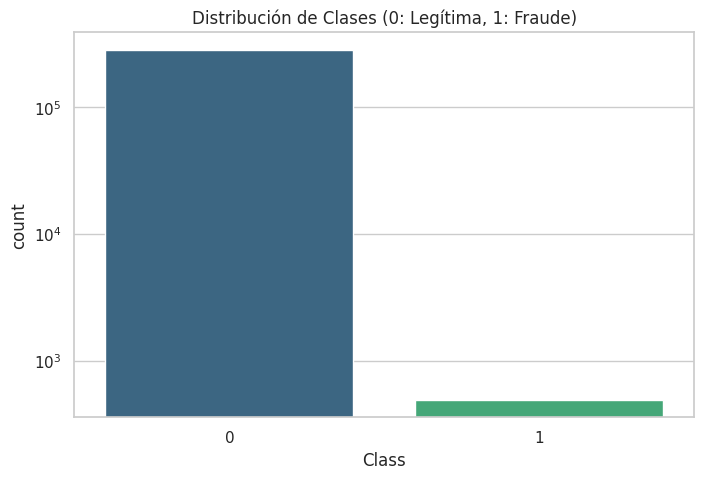

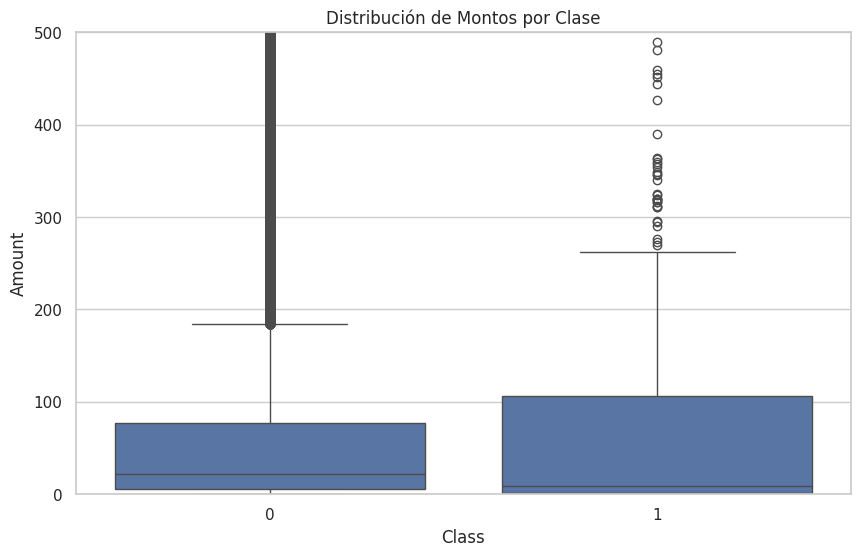

In [ ]:

# 1. Visualizar el desequilibrio de clases
print(df['Class'].value_counts(normalize=True))

plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Distribución de Clases (0: Legítima, 1: Fraude)')
plt.yscale('log') # Usamos escala logarítmica para que el fraude sea visible
plt.show()

# 2. Análisis de la variable 'Amount' (Monto)
# Veremos que los fraudes suelen tener montos específicos
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Distribución de Montos por Clase')
plt.ylim(0, 500) # Limitamos para ver mejor la caja, ya que hay outliers enormes
plt.show()

In [ ]:
# 1. Escalado: 'Amount' tiene muchos outliers, RobustScaler es mejor que StandardScaler
# porque usa la mediana y el rango intercuartílico.
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# Borramos las originales que ya no usaremos (Time y Amount sin escalar)
# Nota: Podrías transformar 'Time' a 'Hora del día', pero por ahora la quitamos.
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# 2. Split Temporal "Manual"
# El dataset está ordenado por tiempo. Tomaremos el último 20% como "el futuro" (Test)
df = df.reset_index(drop=True)
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df.drop('Class', axis=1)
y_train = train_df['Class']
X_test = test_df.drop('Class', axis=1)
y_test = test_df['Class']

print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

Entrenamiento: (227845, 29), Prueba: (56962, 29)


In [ ]:
# Configuramos SMOTE para aumentar la clase minoritaria al 10% de la mayoritaria
# No queremos 50/50 exacto porque sería demasiado artificial, el 10% suele bastar.
sm = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Definimos el modelo LightGBM
# Usamos scale_pos_weight para darle aún más importancia al fraude
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    random_state=42,
    scale_pos_weight=5, # Da 5 veces más peso a los errores en la clase fraude
    n_jobs=-1
)

# Entrenamos
model.fit(X_train_res, y_train_res)

[LightGBM] [Info] Number of positive: 22742, number of negative: 227428
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.271087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 250170, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090906 -> initscore=-2.302620
[LightGBM] [Info] Start training from score -2.302620


LGBMClassifier(learning_rate=0.01, n_estimators=1000, n_jobs=-1,
               random_state=42, scale_pos_weight=5)

In [ ]:
# Obtenemos las probabilidades en lugar de la clase directa
y_probs = model.predict_proba(X_test)[:, 1]

# Queremos encontrar el umbral donde Precision sea aprox 0.09 (1 acierto por cada 11 alertas totales)
# 1 TP / (1 TP + 10 FP) = 0.0909
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Buscamos el umbral más cercano a esa precisión del 9%
target_precision = 0.09
idx = np.argmin(np.abs(precisions - target_precision))
best_threshold = thresholds[idx]

print(f"Umbral elegido para cumplir el ratio 10:1 -> {best_threshold:.4f}")

# Aplicamos el nuevo umbral
y_pred_custom = (y_probs >= best_threshold).astype(int)

Umbral elegido para cumplir el ratio 10:1 -> 0.0245


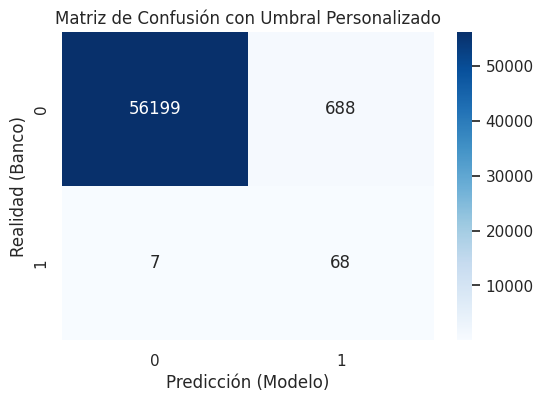

Fraudes detectados (Recall): 68 de 75
Falsos Positivos por cada Fraude: 10.12


In [ ]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (Banco)')
plt.title('Matriz de Confusión con Umbral Personalizado')
plt.show()

# Cálculo del ratio real alcanzado
tp = cm[1, 1]
fp = cm[0, 1]
fn = cm[1, 0]
ratio = fp / tp if tp > 0 else 0

print(f"Fraudes detectados (Recall): {tp} de {tp + fn}")
print(f"Falsos Positivos por cada Fraude: {ratio:.2f}")